In [391]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [392]:
df = pd.read_csv("power_dataset.csv")

df.head()

,node_id,timestamp,voltage,frequency,active_power,reactive_power,load_demand,renewable_output,temperature,humidity,energy_price,power_loss,region_id,stability_index,fault_indicator,attack_label
0,7,2024-01-01 00:00:00,1.028338,50.237769,307.517387,17.897299,508.356414,179.224063,43.626140,57.414603,12.284398,1.648733,1,15.518346,0,0
1,15,2024-01-01 00:01:00,1.053432,50.169283,361.815640,168.500907,393.022613,281.283786,38.587320,79.678709,12.867102,9.830852,3,15.494397,0,1
2,11,2024-01-01 00:02:00,0.945917,50.443237,241.606054,49.128098,213.454317,223.428783,22.136379,80.592591,10.429979,1.663154,3,15.415086,0,0
3,8,2024-01-01 00:03:00,0.924887,50.000674,402.337623,125.638795,319.933523,250.153680,38.039710,51.173218,9.248422,7.629393,1,15.485418,0,0
4,7,2024-01-01 00:04:00,1.007855,49.911674,466.410157,109.596754,462.529359,127.042484,26.576337,62.849441,9.008734,12.087418,4,15.492712,0,0


In [393]:
df.shape


(20000, 16)

In [394]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   node_id           20000 non-null  int64  
 1   timestamp         20000 non-null  object 
 2   voltage           20000 non-null  float64
 3   frequency         20000 non-null  float64
 4   active_power      20000 non-null  float64
 5   reactive_power    20000 non-null  float64
 6   load_demand       20000 non-null  float64
 7   renewable_output  20000 non-null  float64
 8   temperature       20000 non-null  float64
 9   humidity          20000 non-null  float64
 10  energy_price      20000 non-null  float64
 11  power_loss        20000 non-null  float64
 12  region_id         20000 non-null  int64  
 13  stability_index   20000 non-null  float64
 14  fault_indicator   20000 non-null  int64  
 15  attack_label      20000 non-null  int64  
dtypes: float64(11), int64(4), object(1)
memo

In [395]:
df.describe()

,node_id,voltage,frequency,active_power,reactive_power,load_demand,renewable_output,temperature,humidity,energy_price,power_loss,region_id,stability_index,fault_indicator,attack_label
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,10.093850,1.000030,50.000136,275.982591,104.436220,348.976194,151.476443,32.540640,60.053493,8.988598,10.548038,2.498050,15.476746,0.028000,0.10095
std,5.497613,0.050044,0.199824,129.876893,54.736176,144.624413,86.852150,7.208657,17.266076,3.474309,5.490174,1.115643,0.047663,0.164977,0.30127
min,1.000000,0.776720,49.140922,50.058505,10.005576,100.013765,0.004731,20.000164,30.000287,3.001757,1.000106,1.000000,15.269239,0.000000,0.00000
25%,5.000000,0.965726,49.864633,163.004828,56.436668,223.143031,76.125175,26.281981,45.332027,5.923650,5.785867,2.000000,15.447396,0.000000,0.00000
50%,10.000000,1.000265,50.000659,277.183891,104.706238,348.446384,152.035626,32.502302,60.029310,9.007834,10.538021,2.000000,15.479757,0.000000,0.00000
75%,15.000000,1.034294,50.135108,389.453852,151.459487,474.069480,227.091855,38.747978,74.874942,11.992225,15.277615,3.000000,15.509030,0.000000,0.00000
max,19.000000,1.223954,50.749076,499.943795,199.998488,599.960651,299.996815,44.997130,89.998979,14.999733,19.999606,4.000000,15.660982,1.000000,1.00000


In [396]:
df.isnull().sum()

node_id             0
timestamp           0
voltage             0
frequency           0
active_power        0
reactive_power      0
load_demand         0
renewable_output    0
temperature         0
humidity            0
energy_price        0
power_loss          0
region_id           0
stability_index     0
fault_indicator     0
attack_label        0
dtype: int64

In [397]:
print("Fault Distribution:")
print(df['fault_indicator'].value_counts())

print("\nAttack Distribution:")
print(df['attack_label'].value_counts())

Fault Distribution:
fault_indicator
0    19440
1      560
Name: count, dtype: int64

Attack Distribution:
attack_label
0    17981
1     2019
Name: count, dtype: int64


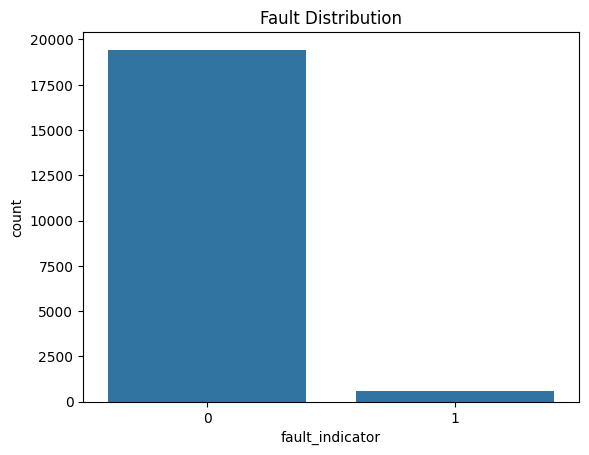

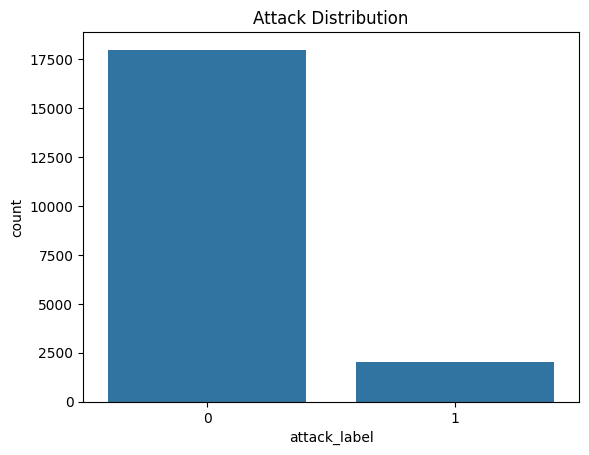

In [398]:
sns.countplot(x=df['fault_indicator'])
plt.title("Fault Distribution")
plt.show()

sns.countplot(x=df['attack_label'])
plt.title("Attack Distribution")
plt.show()

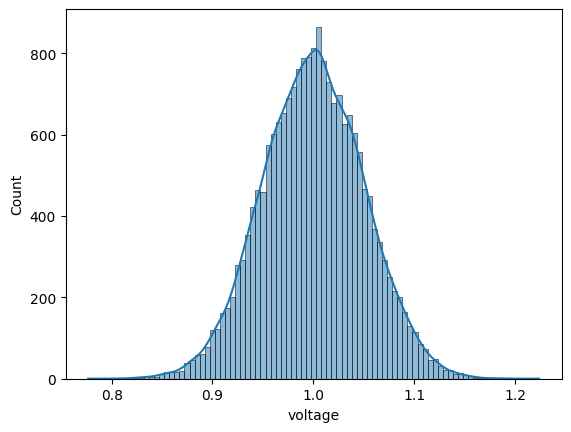

In [399]:
sns.histplot(df['voltage'], kde=True)
plt.show()

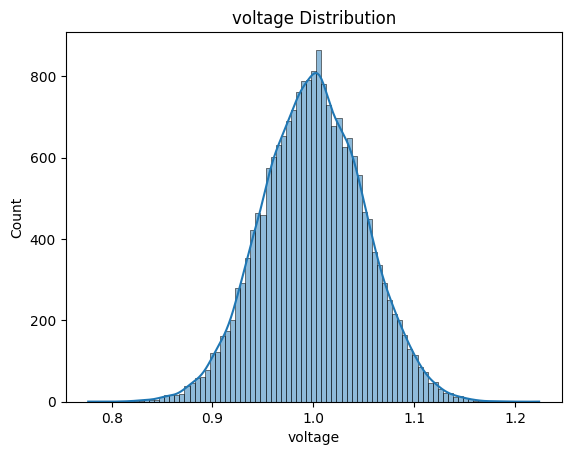

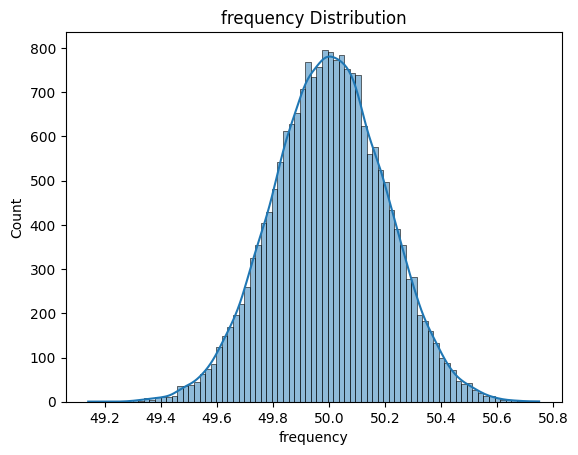

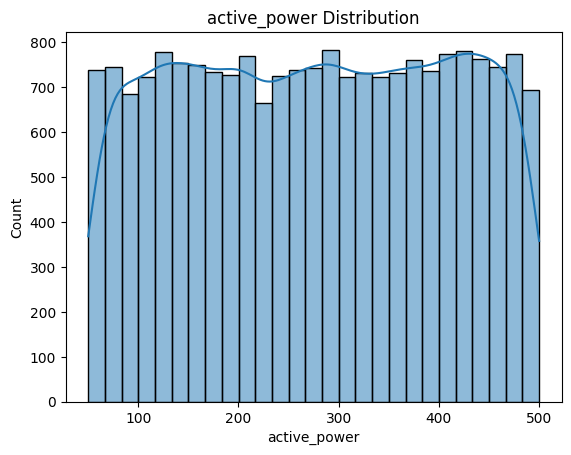

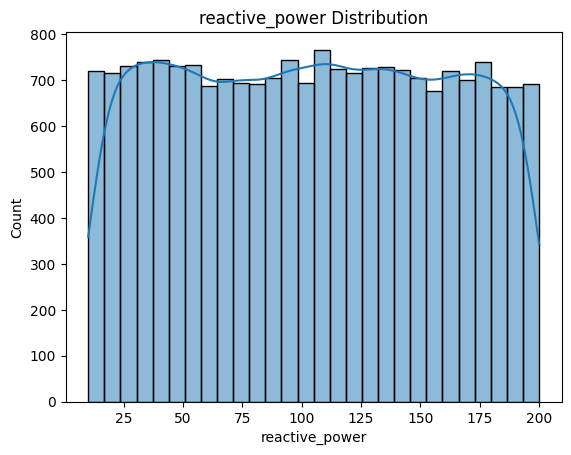

In [400]:
features = ['voltage', 'frequency', 'active_power', 'reactive_power']

for col in features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

In [401]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['node_id', 'timestamp'])

In [402]:
df.head()

,node_id,timestamp,voltage,frequency,active_power,reactive_power,load_demand,renewable_output,temperature,humidity,energy_price,power_loss,region_id,stability_index,fault_indicator,attack_label
15,1,2024-01-01 00:15:00,1.045399,49.871849,204.189879,88.117805,408.453888,56.050106,36.050661,35.872846,14.866078,1.661316,3,15.559405,0,0
72,1,2024-01-01 01:12:00,0.990541,49.750545,255.736116,131.228752,354.982883,204.917731,25.225949,39.688957,3.627317,15.858115,4,15.432298,0,0
75,1,2024-01-01 01:15:00,0.968627,50.279394,170.735644,22.724623,297.229947,248.818421,24.051298,74.662274,9.925369,17.091625,1,15.411550,0,0
84,1,2024-01-01 01:24:00,1.041347,49.970846,344.395490,26.867610,208.172161,177.465013,37.560246,69.615805,5.021679,6.732106,3,15.537794,0,0
94,1,2024-01-01 01:34:00,1.018640,49.932940,340.012714,180.892998,387.879928,245.704293,42.451819,48.012628,5.686864,10.297114,1,15.506905,0,0


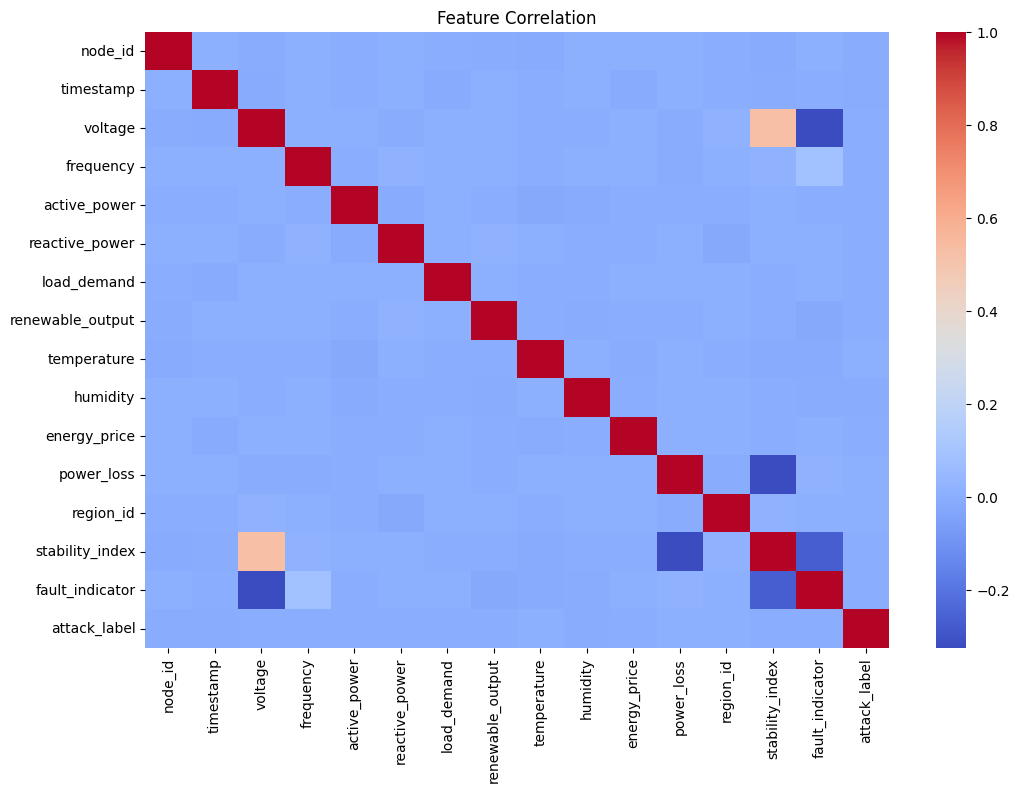

In [403]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [404]:
corr = df.corr()

print(corr['fault_indicator'].sort_values(ascending=False))
print(corr['attack_label'].sort_values(ascending=False))

fault_indicator     1.000000
frequency           0.088528
power_loss          0.017895
energy_price        0.007177
load_demand         0.007031
reactive_power      0.006736
region_id           0.004643
node_id             0.003112
active_power       -0.000478
timestamp          -0.002357
attack_label       -0.002547
humidity           -0.005826
temperature        -0.011479
renewable_output   -0.015969
stability_index    -0.272416
voltage            -0.325491
Name: fault_indicator, dtype: float64
attack_label        1.000000
region_id           0.010628
power_loss          0.008961
temperature         0.005797
voltage            -0.000109
reactive_power     -0.001789
fault_indicator    -0.002547
load_demand        -0.002984
renewable_output   -0.003406
energy_price       -0.003636
active_power       -0.003710
frequency          -0.003994
stability_index    -0.004084
timestamp          -0.004681
humidity           -0.005407
node_id            -0.006747
Name: attack_label, dtype: float64

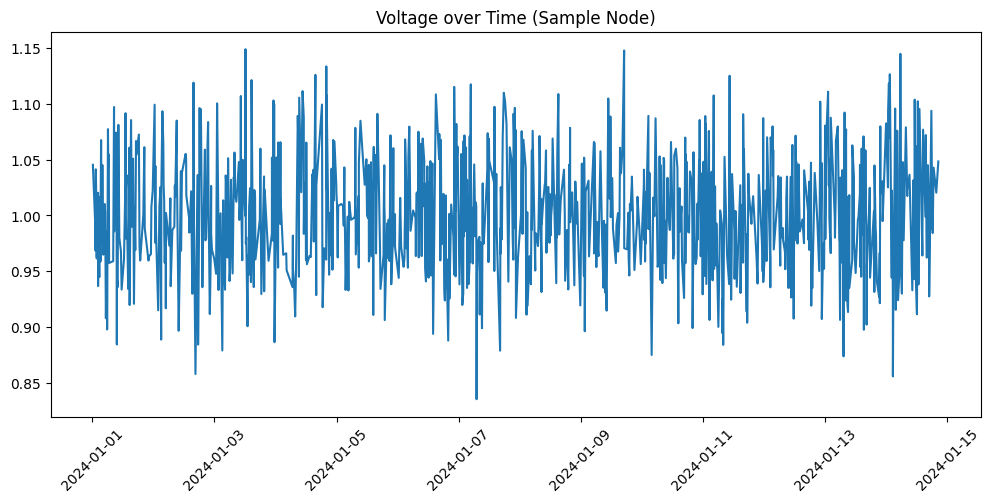

In [405]:
node_sample = df[df['node_id'] == df['node_id'].iloc[0]]

plt.figure(figsize=(12,5))
plt.plot(node_sample['timestamp'], node_sample['voltage'])
plt.title("Voltage over Time (Sample Node)")
plt.xticks(rotation=45)
plt.show()

🧠 8. FEATURE ENGINEERING (IMPORTANT PART)

In [406]:
df['voltage_dev'] = df['voltage'] - df['voltage'].mean()

In [407]:
df['freq_dev'] = df['frequency'] - df['frequency'].mean()

In [408]:
df['power_factor'] = df['active_power'] / (np.sqrt(df['active_power']**2 + df['reactive_power']**2))

In [409]:
df['voltage_roll_mean'] = df.groupby('node_id')['voltage'].rolling(5).mean().reset_index(0,drop=True)

In [410]:
df = df.dropna()

In [411]:
def create_label(row):
    
    if row['fault_indicator'] == 1:
        return 1
    else:
        return 0

df['target'] = df.apply(create_label, axis=1)

df['target'].value_counts()

target
0    19369
1      555
Name: count, dtype: int64

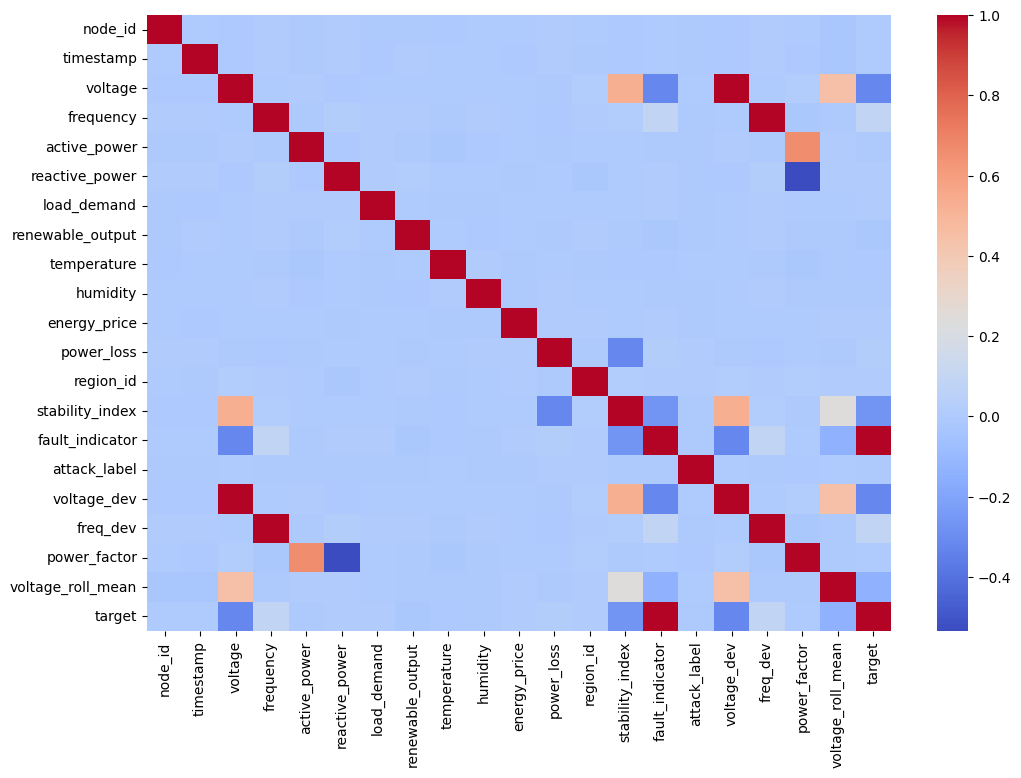

In [412]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [413]:
df['v_f_interaction'] = df['voltage'] * df['frequency']
df['power_ratio'] = df['active_power'] / (df['reactive_power'] + 1e-6)
df['load_power_ratio'] = df['load_demand'] / (df['active_power'] + 1e-6)

In [414]:
df['voltage_lag1'] = df.groupby('node_id')['voltage'].shift(1)
df['voltage_lag2'] = df.groupby('node_id')['voltage'].shift(2)

df['freq_lag1'] = df.groupby('node_id')['frequency'].shift(1)
df['power_lag1'] = df.groupby('node_id')['active_power'].shift(1)

In [415]:
df['voltage_roll_std'] = df.groupby('node_id')['voltage'].rolling(5).std().reset_index(0, drop=True)
df['freq_roll_std'] = df.groupby('node_id')['frequency'].rolling(5).std().reset_index(0, drop=True)

df['power_roll_mean'] = df.groupby('node_id')['active_power'].rolling(5).mean().reset_index(0, drop=True)

In [416]:
df['apparent_power'] = np.sqrt(df['active_power']**2 + df['reactive_power']**2)
df['power_efficiency'] = df['active_power'] / (df['load_demand'] + 1e-6)

In [417]:
df['temp_load_interaction'] = df['temperature'] * df['load_demand']
df['humidity_power_interaction'] = df['humidity'] * df['active_power']

In [418]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day

In [419]:
df['power_change'] = df.groupby('node_id')['active_power'].diff()
df['load_change'] = df.groupby('node_id')['load_demand'].diff()
df['freq_stability'] = df['frequency'].rolling(10).std()

In [420]:
df['power_diff'] = df.groupby('node_id')['active_power'].diff()
df['load_diff'] = df.groupby('node_id')['load_demand'].diff()
df['freq_diff'] = df.groupby('node_id')['frequency'].diff()

df['rolling_mean_freq'] = df.groupby('node_id')['frequency'].rolling(5).mean().reset_index(0,drop=True)
df['rolling_std_freq'] = df.groupby('node_id')['frequency'].rolling(5).std().reset_index(0,drop=True)

In [421]:
df['freq_voltage_ratio'] = df['frequency'] / df['voltage']
df['power_voltage_ratio'] = df['active_power'] / df['voltage']
df['stability_power'] = df['stability_index'] * df['active_power']

In [422]:
df['voltage_spike'] = (df['voltage'] - df['voltage_roll_mean']).abs()
df['freq_spike'] = (df['frequency'] - df['rolling_mean_freq']).abs()

df['power_spike'] = df['active_power'].diff().abs()

In [423]:
df['voltage_z'] = (df['voltage'] - df['voltage'].mean()) / df['voltage'].std()
df['freq_z'] = (df['frequency'] - df['frequency'].mean()) / df['frequency'].std()

In [424]:
df['power_acceleration'] = df.groupby('node_id')['active_power'].diff().diff()

In [425]:
df['voltage_roll_max'] = df.groupby('node_id')['voltage'].rolling(5).max().reset_index(0, drop=True)
df['voltage_roll_min'] = df.groupby('node_id')['voltage'].rolling(5).min().reset_index(0, drop=True)

In [426]:
df['voltage_ratio'] = df['voltage'] / (df['voltage_roll_mean'] + 1e-6)

In [427]:
df = df.fillna(method='ffill')


C:\Users\Subhalaxmi Sahoo\AppData\Local\Temp\ipykernel_20512\3984534036.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


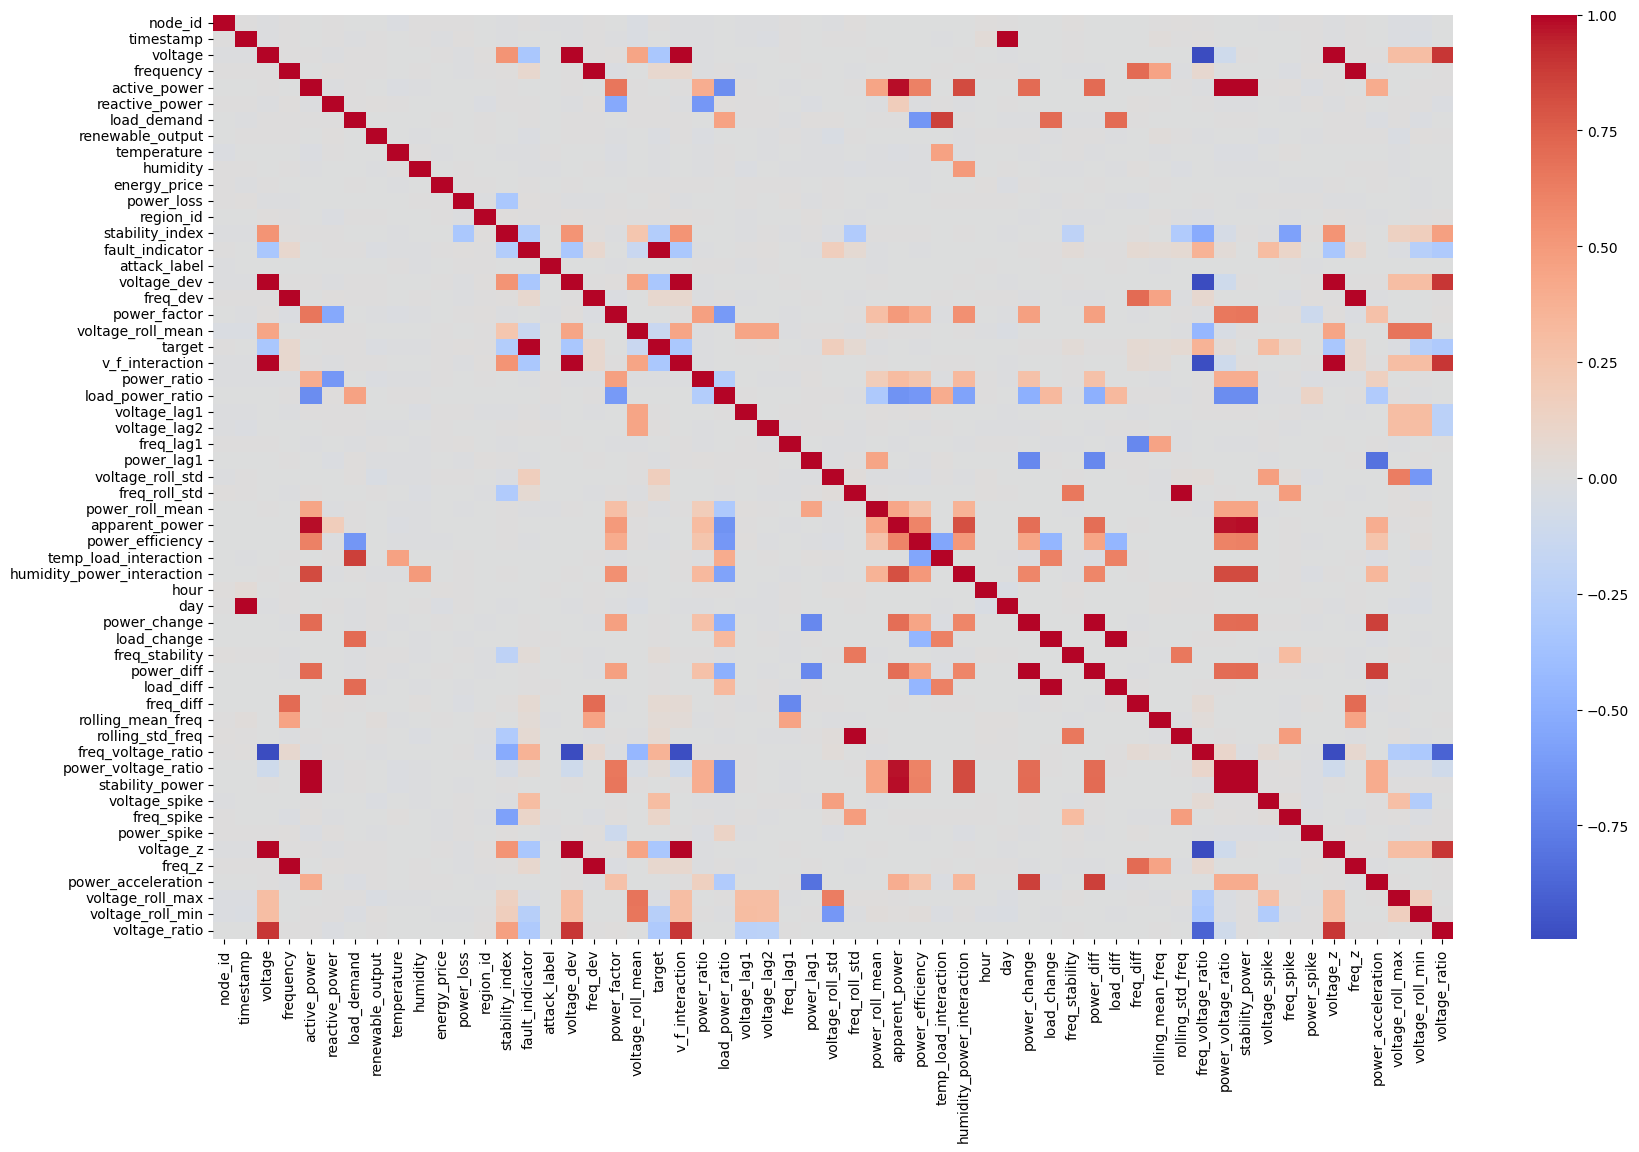

In [428]:
plt.figure(figsize=(20,12))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [429]:
df.isnull().sum()

node_id                       0
timestamp                     0
voltage                       0
frequency                     0
active_power                  0
reactive_power                0
load_demand                   0
renewable_output              0
temperature                   0
humidity                      0
energy_price                  0
power_loss                    0
region_id                     0
stability_index               0
fault_indicator               0
attack_label                  0
voltage_dev                   0
freq_dev                      0
power_factor                  0
voltage_roll_mean             0
target                        0
v_f_interaction               0
power_ratio                   0
load_power_ratio              0
voltage_lag1                  1
voltage_lag2                  2
freq_lag1                     1
power_lag1                    1
voltage_roll_std              4
freq_roll_std                 4
power_roll_mean               4
apparent

In [430]:
df = df.dropna()

In [431]:
df.shape

(19915, 57)

In [432]:
df.head()

,node_id,timestamp,voltage,frequency,active_power,reactive_power,load_demand,renewable_output,temperature,humidity,...,stability_power,voltage_spike,freq_spike,power_spike,voltage_z,freq_z,power_acceleration,voltage_roll_max,voltage_roll_min,voltage_ratio
194,1,2024-01-01 03:14:00,0.958711,50.246817,396.865162,77.942610,104.523827,31.984580,35.627374,37.793561,...,6127.374115,0.029972,0.116678,99.164809,-0.825765,1.235394,200.679760,1.016976,0.944641,0.969684
199,1,2024-01-01 03:19:00,1.013264,50.116665,104.215716,23.468135,391.645609,249.219011,40.759005,38.163772,...,1615.723187,0.025324,0.038447,292.649446,0.264251,0.583778,-391.814255,1.013264,0.944641,1.025632
209,1,2024-01-01 03:29:00,1.067550,49.786549,251.643880,184.855350,255.204611,189.956971,43.241296,59.785612,...,3897.655022,0.055028,0.323516,147.428163,1.348902,-1.068966,440.077610,1.067550,0.958711,1.054346
221,1,2024-01-01 03:41:00,0.975090,49.981147,377.057902,118.628315,499.135382,145.625587,21.177420,77.451363,...,5843.161522,0.029843,0.062541,125.414023,-0.498488,-0.094701,-22.014141,1.067550,0.958711,0.970303
239,1,2024-01-01 03:59:00,1.045195,50.048883,109.969078,69.297465,137.774049,81.910252,22.587490,58.023462,...,1709.558114,0.033233,0.012870,267.088824,0.902234,0.244422,-392.502847,1.067550,0.958711,1.032839


In [433]:
corr = df.corr()

corr_target = corr['target'].abs().sort_values(ascending=False)
print(corr_target.head(20))

target                1.000000
fault_indicator       1.000000
freq_voltage_ratio    0.364923
voltage               0.324855
voltage_dev           0.324855
voltage_z             0.324855
v_f_interaction       0.316792
voltage_spike         0.304079
voltage_ratio         0.298697
stability_index       0.270636
voltage_roll_min      0.246652
voltage_roll_std      0.174191
voltage_roll_mean     0.140158
freq_spike            0.108190
freq_z                0.086793
freq_dev              0.086793
frequency             0.086793
freq_diff             0.060317
freq_roll_std         0.059139
rolling_std_freq      0.059139
Name: target, dtype: float64


In [434]:
corr_matrix = df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

protected_cols = ['target', 'fault_indicator', 'attack_label']

to_drop = [col for col in upper.columns 
           if any(upper[col] > 0.9) and col not in protected_cols]

df = df.drop(columns=to_drop)

In [435]:
df['target'] = df['fault_indicator']

In [436]:
from xgboost import XGBClassifier

X = df.drop(columns=['target', 'timestamp'])
y = df['target']

model = XGBClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)

fault_indicator               0.999497
voltage                       0.000226
frequency                     0.000104
voltage_roll_min              0.000075
stability_index               0.000043
voltage_ratio                 0.000033
voltage_spike                 0.000023
load_change                   0.000000
power_roll_mean               0.000000
power_efficiency              0.000000
temp_load_interaction         0.000000
humidity_power_interaction    0.000000
hour                          0.000000
power_change                  0.000000
freq_stability                0.000000
dtype: float32

In [437]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19915 entries, 194 to 19961
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   node_id                     19915 non-null  int64         
 1   timestamp                   19915 non-null  datetime64[ns]
 2   voltage                     19915 non-null  float64       
 3   frequency                   19915 non-null  float64       
 4   active_power                19915 non-null  float64       
 5   reactive_power              19915 non-null  float64       
 6   load_demand                 19915 non-null  float64       
 7   renewable_output            19915 non-null  float64       
 8   temperature                 19915 non-null  float64       
 9   humidity                    19915 non-null  float64       
 10  energy_price                19915 non-null  float64       
 11  power_loss                  19915 non-null  float64      

In [438]:
print(df['target'].value_counts())

target
0    19360
1      555
Name: count, dtype: int64


In [439]:
df.describe()

,node_id,timestamp,voltage,frequency,active_power,reactive_power,load_demand,renewable_output,temperature,humidity,...,freq_stability,freq_diff,rolling_mean_freq,voltage_spike,freq_spike,power_spike,power_acceleration,voltage_roll_max,voltage_roll_min,voltage_ratio
count,19915.000000,19915,19915.000000,19915.000000,19915.000000,19915.000000,19915.000000,19915.000000,19915.000000,19915.000000,...,19915.000000,19915.000000,19915.000000,1.991500e+04,19915.000000,19915.000000,19915.000000,19915.000000,19915.000000,19915.000000
mean,10.098318,2024-01-07 23:21:56.679889664,1.000045,50.000043,275.981887,104.470310,348.936794,151.510021,32.532232,60.051355,...,0.194126,0.000023,50.000012,3.570991e-02,0.142332,149.988912,0.067019,1.058334,0.941558,1.000036
min,1.000000,2024-01-01 00:38:00,0.776720,49.140922,50.058505,10.005576,100.013765,0.004731,20.000164,30.000287,...,0.051676,-1.183149,49.646325,7.701307e-07,0.000001,0.005311,-840.882647,0.951041,0.776720,0.820720
25%,5.000000,2024-01-04 12:23:30,0.965732,49.864761,162.897133,56.460195,223.141694,76.240201,26.277158,45.329469,...,0.161241,-0.192748,49.939671,1.429246e-02,0.057237,59.781390,-237.152521,1.035283,0.921323,0.969936
50%,10.000000,2024-01-07 23:22:00,1.000279,50.000535,277.249877,104.750253,348.277897,152.041258,32.490926,60.031028,...,0.191507,0.000992,49.999927,3.021854e-02,0.120758,132.124974,-3.747324,1.056491,0.942992,1.000147
75%,15.000000,2024-01-11 10:20:30,1.034327,50.135003,389.559067,151.486218,474.050123,227.078142,38.734045,74.888025,...,0.224903,0.189722,50.061123,5.116568e-02,0.203891,224.975229,233.493492,1.080020,0.963991,1.030415
max,19.000000,2024-01-14 21:19:00,1.223954,50.749076,499.943795,199.998488,599.960651,299.996815,44.997130,89.998979,...,0.405258,1.133275,50.332952,2.122768e-01,0.758010,445.965013,863.032002,1.223954,1.065813,1.209825
std,5.495529,NaN,0.050054,0.199747,129.927407,54.739152,144.646185,86.819504,7.208393,17.272163,...,0.046304,0.282319,0.090169,2.706959e-02,0.107069,105.875846,317.934780,0.033424,0.033447,0.044844


In [440]:
y = df['target']

X = df.drop(columns=[
    'target',
    'fault_indicator',
    'attack_label',
    'timestamp'
])

In [441]:
df.shape

(19915, 44)

In [442]:
X = X.select_dtypes(include=['int64', 'float64'])

In [443]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [444]:
print("Train:", y_train.value_counts())
print("Test:", y_test.value_counts())

Train: target
0    15488
1      444
Name: count, dtype: int64
Test: target
0    3872
1     111
Name: count, dtype: int64


In [445]:
from xgboost import XGBClassifier
import pandas as pd

temp_model = XGBClassifier(eval_metric='mlogloss')
temp_model.fit(X_train, y_train)

importance = pd.Series(temp_model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(20).index

X_train_res = X_train[top_features]
X_test = X_test[top_features]

In [446]:
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train_res, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [447]:
print("Train_main:", y_train_main.value_counts())
print("Val:", y_val.value_counts())

Train_main: target
0    12390
1      355
Name: count, dtype: int64
Val: target
0    3098
1      89
Name: count, dtype: int64


In [448]:
from xgboost import XGBClassifier


from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    
    objective='binary:logistic',   
    eval_metric='logloss',         
    
    random_state=42
)
xgb.fit(
    X_train_main, y_train_main,
    eval_set=[(X_val, y_val)],
    
    verbose=False
)

xgb_pred = xgb.predict(X_test)

In [449]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

Accuracy: 0.9987446648255084
[[3870    2]
 [   3  108]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3872
           1       0.98      0.97      0.98       111

    accuracy                           1.00      3983
   macro avg       0.99      0.99      0.99      3983
weighted avg       1.00      1.00      1.00      3983



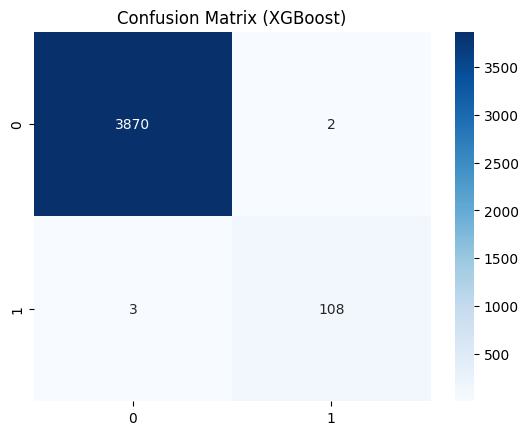

In [450]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (XGBoost)")
plt.show()